<!-- Encabezado con dos logos -->
<table style="width:100%; border:0px">
  <tr style="border:0px">
    <td align="left" style="border:0px">
      <img src="https://www.uclm.es/images/logos/Logo_uclm_40.png" alt="Universidad" height="80">
    </td>
    <td align="right" style="border:0px">
      <img src="https://simd.i3a.uclm.es/wp-content/uploads/2025/01/LOGO-Pie-SIMD-1.webp" alt="Grupo de Investigación" height="80">
    </td>
  </tr>
</table>

<br>

<!-- Título del documento -->
<h1 align="center"> Homework 2.- EKF Localisation </h1>

<!-- Información institucional -->
<p align="center">
  <strong>Degree in Computer Science</strong>
  <br>  
  Universidad de Castilla-La Mancha  
  <br>
  <strong>Teacher:</strong> Jesús Martínez Gómez (Jesus.Martinez@uclm.es)
</p>

# Presentation

## Extended Kalman Filter

In this notebook you will implement the core steps of **Extended Kalman Filter (EKF) Localisation** for a mobile robot moving in a 2D world with a simulated LIDAR.

### What you must implement

Complete the following functions in the **EKF localisation** section:

- `ekf_motion_jacobian`
- `ekf_motion_model`
- `ekf_initialise`
- `ekf_predict`

### What is already provided

The notebook already includes:

- Global parameters
- Reusable helpers for angles, motion, particles and LIDAR
- World generation and robot simulation
- LIDAR simulation
- Navigation and simulation engine
- Visualisation tools
- Test cases and experiment runners

Please modify **only** the EKF section unless explicitly instructed otherwise.

### Evaluation overview

Your work will be evaluated in three blocks:

1. **EKF implementation** validated on various trajectories with known and unknown initial poses.
2. **Analysis** of EKF results.
3. **Experimental study** of the influence of noise parameters.

# Evaluation Details

## Assessment rubric summary

The practice will be graded with the following weights:

- **50%** EKF implementation
- **25%** Analysis of the incluence of the known/unknown initial pose
- **25%** Study of the influence of noise parameters

### Analysis and studies

Feel free to genreate plots and graphs to support your discussion.

## Extended Kalman Filter (EKF) formulation

In this homework, we estimate the robot state using an **Extended Kalman Filter (EKF)**.

The state of the robot is defined as:

$$
x = (x, y, \theta)
$$

where $(x, y)$ is the position and $\theta$ is the orientation.

---

### Motion model

The robot evolves according to the odometry commands $(v, \omega)$:

$$
x' = f(x, u)
$$

with:

$$
x' =
\begin{bmatrix}
x + v \Delta t \cos(\theta) \
y + v \Delta t \sin(\theta) \
\theta + \omega \Delta t
\end{bmatrix}.
$$

* $u = (v, \omega)$: control input (linear and angular velocity)
* $\Delta t$: time step
* $f(\cdot)$: nonlinear motion model --> this is the reason to use Extended KF

---

### Observation model

The robot observes distances to known landmarks:

$$
z_i = h(x) = \sqrt{(x - x_i)^2 + (y - y_i)^2}
$$

* $(x_i, y_i)$: position of landmark $i$
* $z_i$: measured distance
* $h(\cdot)$: nonlinear observation model

---

### EKF structure

At each time step, the EKF maintains:

* $\mu$: **state estimate** (mean)
* $\Sigma$: **state uncertainty** (covariance matrix)

---

### Prediction step

Using the motion model:

$$
\mu^- = f(\mu, u)
$$

$$
\Sigma^- = G \Sigma G^T + Q
$$

* $G = \frac{\partial f}{\partial x}$: Jacobian of the motion model
* $Q$: process noise (uncertainty in odometry)

---

### Correction step (already covered in the Assignment)

For each observed landmark:

$$
K = \Sigma^- H^T (H \Sigma^- H^T + R)^{-1}
$$

$$
\mu^+ = \mu^- + K(z - h(\mu^-))
$$

$$
\Sigma^+ = (I - K H)\Sigma^-
$$

* $H = \frac{\partial h}{\partial x}$: Jacobian of the observation model
* $R$: measurement noise
* $z - h(\mu^-)$: innovation (measurement error)

---

### Key idea

The EKF alternates between:

* **Prediction**, using the motion model
* **Correction**, using landmark observations

## Imports and reusable helpers **(do not modify / add new methods if needed)**

In [124]:
import copy
import math
import pandas as pd
from dataclasses import dataclass
from typing import Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
from matplotlib import animation

plt.rcParams["animation.embed_limit"] = 80.0

# ---------------------------------------------------------------------------
# angles, poses
# ---------------------------------------------------------------------------
def wrap_pi(angle):
    """Wrap angle(s) to [-pi, pi). Works with scalars and NumPy arrays."""
    return (np.asarray(angle) + np.pi) % (2.0 * np.pi) - np.pi


def angle_diff(a, b):
    """Smallest signed angular difference a - b."""
    return wrap_pi(np.asarray(a) - np.asarray(b))


def apply_motion(x: float, y: float, th: float, motion_local: np.ndarray) -> np.ndarray:
    """Apply a planar motion expressed in the local frame of heading th."""
    dx_local, dy_local, dth = np.asarray(motion_local, dtype=float)
    c = math.cos(th)
    s = math.sin(th)
    nx = x + c * dx_local - s * dy_local
    ny = y + s * dx_local + c * dy_local
    nth = float(wrap_pi(th + dth))
    return np.array([nx, ny, nth], dtype=float)

# ---------------------------------------------------------------------------
# LIDAR
# ---------------------------------------------------------------------------
def lidar_ray_angles(n_rays: int, fov: float) -> np.ndarray:
    return np.linspace(-fov / 2.0, fov / 2.0, int(n_rays), dtype=float)


def lidar_ray_directions(theta: float, ray_angles: np.ndarray) -> np.ndarray:
    return wrap_pi(theta + np.asarray(ray_angles, dtype=float))


def clip_lidar_ranges(ranges: np.ndarray, range_max: float) -> np.ndarray:
    return np.clip(np.asarray(ranges, dtype=float), 0.0, float(range_max))

# ---------------------------------------------------------------------------
# Error estimation
# ---------------------------------------------------------------------------

def pose_error_xy(true_xyth: np.ndarray, est_xyth: np.ndarray) -> np.ndarray:
    return np.sqrt(np.sum((true_xyth[:, :2] - est_xyth[:, :2])**2, axis=1))

def heading_error(true_xyth: np.ndarray, est_xyth: np.ndarray) -> np.ndarray:
    return np.abs(np.array([wrap_pi(a - b) for a, b in zip(true_xyth[:, 2], est_xyth[:, 2])]))

# ---------------------------------------------------------------------------
# Random number generator helpers
# ---------------------------------------------------------------------------
def spawn_rngs(master_seed: int) -> dict:
    """Create independent generators derived from a single visible master seed."""
    seed_seq = np.random.SeedSequence(int(master_seed))
    labels = ["world", "sensor", "mcl", "goal"]
    children = seed_seq.spawn(len(labels))
    return {label: np.random.default_rng(child) for label, child in zip(labels, children)}

## Global parameters (**add/modify values for the experimentation**) if needed


In [125]:
# ---------------------------------------------------------------------------
# Global parameters (single visible configuration zone)
# ---------------------------------------------------------------------------

MASTER_SEED = 7

# Environment
WORLD_H = 80
WORLD_W = 120
CELL_SIZE = 0.05  # metres per cell
SCATTERED_SMALL_BLOCKS = 8

# Robot and simulation
DT = 0.1
V_MAX = 0.15
W_MAX = 1.2
V_LINEAR = 0.15
BODY_RADIUS = 0.10
N_STEPS = 300

# LIDAR
LIDAR_N_RAYS = 40
LIDAR_RANGE_MAX = 8.0
LIDAR_FOV = 2.0 * math.pi
LIDAR_STEP = 0.02
LIDAR_NOISE_STD = 0.01
LIDAR_CMAP_NAME = "coolwarm"
LIDAR_ALPHA = 0.30

# LANDMARKS
N_LANDMARKS = 4
LANDMARK_MIN_SEPARATION = 0.45   # metres
LANDMARK_OBS_CLEARANCE = 0.12    # metres

# EKF
LANDMARK_SENSOR_STD = 0.08                 # measurement noise (fixed R)
EKF_ODOM_V_STD = 0.04                      # translational odometry noise
EKF_PROCESS_X_STD = EKF_ODOM_V_STD         # process noise in x (m)
EKF_PROCESS_Y_STD = EKF_ODOM_V_STD         # process noise in y (m)
EKF_ODOM_W_STD = math.radians(4.0)         # angular odometry noise
EKF_PROCESS_TH_STD = EKF_ODOM_W_STD        # process noise in heading (rad)

EKF_SIGMA_X_KNOWN_POSE = 0.05**2
EKF_SIGMA_Y_KNOWN_POSE = 0.05**2
EFK_SIGMA_TH_KNOWN_POSE = math.radians(4.0)**2

EKF_SIGMA_X_UNKNOWN_POSE = 0.5**2
EKF_SIGMA_Y_UNKNOWN_POSE = 0.5**2
EFK_SIGMA_TH_UNKNOWN_POSE = math.radians(40.0)**2

# Navigation
NAV_MIN_FRONT_CLEARANCE = 0.20
NAV_CLEARANCE = 0.50
NAV_TURN_GAIN = 1.8

## 2D model of the world and landmarks (**do not modify**)

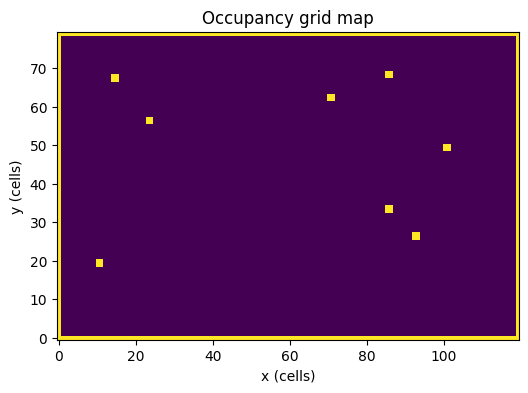

In [126]:
def make_world(h: int, w: int, rng: np.random.Generator) -> np.ndarray:
    grid = np.zeros((h, w), dtype=np.uint8)
    grid[0, :] = 1
    grid[-1, :] = 1
    grid[:, 0] = 1
    grid[:, -1] = 1

    for _ in range(SCATTERED_SMALL_BLOCKS):
        y = int(rng.integers(5, h - 5))
        x = int(rng.integers(5, w - 5))
        grid[y:y + 2, x:x + 2] = 1

    return grid

def world_to_cell(x_m: float, y_m: float):
    c = int(x_m / CELL_SIZE)
    r = int(y_m / CELL_SIZE)
    return r, c

def in_bounds_rc(r: int, c: int, grid: np.ndarray) -> bool:
    return 0 <= r < grid.shape[0] and 0 <= c < grid.shape[1]

def is_occupied_xy(x_m: float, y_m: float, grid: np.ndarray) -> bool:
    r, c = world_to_cell(x_m, y_m)
    if not in_bounds_rc(r, c, grid):
        return True
    return bool(grid[r, c] == 1)

# ---------------------------------------------------------------------------
# Landmark generation
# ---------------------------------------------------------------------------

def landmark_is_valid(x: float, y: float, grid: np.ndarray,
                      min_clearance: float = LANDMARK_OBS_CLEARANCE) -> bool:
    if is_occupied_xy(x, y, grid):
        return False
    for ang in np.linspace(0.0, 2.0 * math.pi, 12, endpoint=False):
        px = x + min_clearance * math.cos(ang)
        py = y + min_clearance * math.sin(ang)
        if is_occupied_xy(px, py, grid):
            return False
    return True


def generate_landmarks(grid: np.ndarray,
                       rng: np.random.Generator,
                       n_landmarks: int = N_LANDMARKS,
                       min_separation: float = LANDMARK_MIN_SEPARATION) -> np.ndarray:
    """
    Generate landmarks in free space, separated from obstacles and from each other
    """
    landmarks = []
    h, w = grid.shape

    for _ in range(10000):
        if len(landmarks) >= n_landmarks:
            break

        x = float(rng.uniform(CELL_SIZE, w * CELL_SIZE - CELL_SIZE))
        y = float(rng.uniform(CELL_SIZE, h * CELL_SIZE - CELL_SIZE))

        if not landmark_is_valid(x, y, grid):
            continue

        if any(math.hypot(x - lx, y - ly) < min_separation for lx, ly in landmarks):
            continue

        landmarks.append((x, y))

    if len(landmarks) < n_landmarks:
        raise RuntimeError("Could not place all landmarks with the current constraints.")

    return np.asarray(landmarks, dtype=float)


preview_rngs = spawn_rngs(MASTER_SEED)
grid_preview = make_world(WORLD_H, WORLD_W, preview_rngs["world"])

plt.figure(figsize=(7, 4))
plt.imshow(grid_preview, origin="lower", interpolation="nearest")
plt.title("Occupancy grid map")
plt.xlabel("x (cells)")
plt.ylabel("y (cells)")
plt.show()

## Robot simulator (**do not modify**)


In [127]:
@dataclass
class RobotState:
    x: float
    y: float
    th: float

@dataclass
class SimConfig:
    dt: float = DT
    v_max: float = V_MAX
    w_max: float = W_MAX
    body_radius: float = BODY_RADIUS

def _collides(x: float, y: float, grid: np.ndarray, body_radius: float) -> bool:
    for ang in np.linspace(0.0, 2.0 * math.pi, 8, endpoint=False):
        px = x + body_radius * math.cos(ang)
        py = y + body_radius * math.sin(ang)
        if is_occupied_xy(px, py, grid):
            return True
    return False

def step_sim(state_true: RobotState, v_cmd: float, w_cmd: float, grid: np.ndarray, cfg: SimConfig) -> RobotState:
    v = float(np.clip(v_cmd, -cfg.v_max, cfg.v_max))
    w = float(np.clip(w_cmd, -cfg.w_max, cfg.w_max))

    motion_local = np.array([v * cfg.dt, 0.0, w * cfg.dt], dtype=float)
    nx, ny, nth = apply_motion(state_true.x, state_true.y, state_true.th, motion_local)

    if _collides(float(nx), float(ny), grid, cfg.body_radius):
        nx, ny = state_true.x, state_true.y

    return RobotState(float(nx), float(ny), float(nth))

def pose_error(true_pose: RobotState, est_pose: Optional[RobotState]) -> Optional[float]:
    if est_pose is None:
        return None
    return float(math.hypot(true_pose.x - est_pose.x, true_pose.y - est_pose.y))

def sample_random_free_pose(grid: np.ndarray, rng: np.random.Generator, margin: float = BODY_RADIUS) -> RobotState:
    h, w = grid.shape
    for _ in range(10000):
        x = float(rng.uniform(margin, w * CELL_SIZE - margin))
        y = float(rng.uniform(margin, h * CELL_SIZE - margin))
        th = float(rng.uniform(-math.pi, math.pi))
        if not _collides(x, y, grid, margin):
            return RobotState(x, y, th)
    raise RuntimeError("Could not sample a free pose.")

## LIDAR simulation (**do not modify**)


In [128]:
def cast_single_ray(px: float, py: float, abs_ang: float, grid: np.ndarray,
                    range_max: float = LIDAR_RANGE_MAX, step: float = LIDAR_STEP) -> float:
    dist = 0.0
    while dist < range_max:
        x = px + dist * math.cos(abs_ang)
        y = py + dist * math.sin(abs_ang)
        if is_occupied_xy(x, y, grid):
            return float(dist)
        dist += step
    return float(range_max)


def lidar_scan(state_true: RobotState,
               grid: np.ndarray,
               rng: np.random.Generator,
               n_rays: int = LIDAR_N_RAYS,
               fov: float = LIDAR_FOV,
               range_max: float = LIDAR_RANGE_MAX,
               step: float = LIDAR_STEP,
               noise_std: float = LIDAR_NOISE_STD):

    angles = lidar_ray_angles(n_rays, fov)
    abs_angles = lidar_ray_directions(state_true.th, angles)
    dists = np.empty(len(angles), dtype=float)

    for i, abs_ang in enumerate(abs_angles):
        dists[i] = cast_single_ray(state_true.x, state_true.y, float(abs_ang), grid,
                                   range_max=range_max, step=step)

    if noise_std > 0.0:
        dists = dists + rng.normal(0.0, noise_std, size=dists.shape)

    dists = clip_lidar_ranges(dists, range_max)
    return angles, dists


## Navigation  (**do not modify**)


In [129]:
@dataclass
class NavParams:
    min_front_clearance: float = NAV_MIN_FRONT_CLEARANCE
    clearance: float = NAV_CLEARANCE
    v_linear: float = V_LINEAR
    v_max: float = V_MAX
    w_max: float = W_MAX
    turn_gain: float = NAV_TURN_GAIN


def goal_relative_angle(pose: RobotState, goal_xy):
    gx, gy = goal_xy
    ang_goal_abs = math.atan2(gy - pose.y, gx - pose.x)
    return float(angle_diff(ang_goal_abs, pose.th))


def front_clearance(scan_angles, scan_dists):
    front = np.abs(scan_angles) < math.radians(25)
    return float(np.min(scan_dists[front])) if np.any(front) else float(np.min(scan_dists))


def angular_command_from_heading(selected_heading: float, nav: NavParams):
    return float(np.clip(nav.turn_gain * float(wrap_pi(selected_heading)), -nav.w_max, nav.w_max))


def choose_command(pose_for_control: RobotState, goal_xy, scan_angles, scan_dists, prev_cmd, nav: NavParams):
    goal_heading = goal_relative_angle(pose_for_control, goal_xy)
    selected_heading = goal_heading
    v = nav.v_linear
    w = angular_command_from_heading(selected_heading, nav)

    debug = {
        "mode": "normal",
        "goal_heading": goal_heading,
        "selected_heading": selected_heading,
    }
    return float(v), float(w), debug


def correct_command_for_safety(v: float, w: float, scan_angles, scan_dists, nav: NavParams):
    v = float(np.clip(v, -nav.v_max, nav.v_max))
    w = float(np.clip(w, -nav.w_max, nav.w_max))

    if front_clearance(scan_angles, scan_dists) < nav.min_front_clearance:
        v = 0.0

    return v, w


# Homework 2 — EKF localisation

This homework reuses the same simulator components from Homework 1:

- world definition
- robot simulator
- LIDAR
- navigation

The new part is **landmark-based localisation** using an **Extended Kalman Filter (EKF)**.

The EKF state is $x = (x, y, \theta)$.

For landmark $i$, the observation model is

$$
z_i = \sqrt{(x-x_i)^2 + (y-y_i)^2}.
$$

In this homework, the filter uses:

- odometry commands $(v, \omega)$ as the motion input,
- visible landmarks extracted from the current LIDAR scan,
- sequential EKF updates, one landmark at a time.



## Landmark generation and visibility  (**do not modify**)

Landmarks are generated in free space, kept away from obstacles, and do not modify the occupancy map.


In [130]:
# ---------------------------------------------------------------------------
# Landmarks and observations
# ---------------------------------------------------------------------------

def visible_landmarks(robot_pose: RobotState,
                      landmarks: np.ndarray,
                      scan_angles: np.ndarray,
                      scan_dists: np.ndarray,
                      tol_angle: float = math.radians(3.0),
                      tol_range: float = 0.10):
    visible_ids = []
    visible_dists = []

    scan_angles = np.asarray(scan_angles, dtype=float)
    scan_dists = np.asarray(scan_dists, dtype=float)
    landmarks = np.asarray(landmarks, dtype=float)

    for i, (lx, ly) in enumerate(landmarks):
        dx = float(lx - robot_pose.x)
        dy = float(ly - robot_pose.y)
        dist = float(math.hypot(dx, dy))
        rel_ang = float(wrap_pi(math.atan2(dy, dx) - robot_pose.th))

        ang_diffs = np.array([abs(wrap_pi(a - rel_ang)) for a in scan_angles])
        candidate_js = np.where(ang_diffs <= tol_angle)[0]

        for j in candidate_js:
            if dist <= float(scan_dists[j]) + tol_range:
                visible_ids.append(i)
                visible_dists.append(dist)
                break

    return np.asarray(visible_ids, dtype=int), np.asarray(visible_dists, dtype=float)


def noisy_landmark_measurements(robot_pose: RobotState,
                                landmarks: np.ndarray,
                                visible_ids: np.ndarray,
                                rng: np.random.Generator,
                                sensor_std: float = LANDMARK_SENSOR_STD):
    zs = []
    for i in np.asarray(visible_ids, dtype=int):
        lx, ly = landmarks[i]
        d = math.hypot(lx - robot_pose.x, ly - robot_pose.y)
        zs.append(d + float(rng.normal(0.0, sensor_std)))
    return np.asarray(zs, dtype=float)



## Observation model and jacobian  (**do not modify**)

For landmark $(x_i, y_i)$, the expected observation is

$$
h(x) = \sqrt{(x-x_i)^2 + (y-y_i)^2}.
$$


In [131]:
def observation_model(state: np.ndarray, landmark: np.ndarray) -> float:
    x, y, theta = np.asarray(state, dtype=float)
    lx, ly = np.asarray(landmark, dtype=float)
    return float(math.hypot(x - lx, y - ly))


def observation_jacobian(state: np.ndarray, landmark: np.ndarray) -> np.ndarray:
    x, y, theta = np.asarray(state, dtype=float)
    lx, ly = np.asarray(landmark, dtype=float)

    dx = float(x - lx)
    dy = float(y - ly)
    d = math.sqrt(max(dx * dx + dy * dy, 1e-12))

    H = np.zeros((1, 3), dtype=float)
    H[0, 0] = dx / d
    H[0, 1] = dy / d
    H[0, 2] = 0.0
    return H

## Motion model and Jacobian

The motion model describes how the robot state evolves given the control input $u = (v, \omega)$:

$$
x' = f(x, u)
$$

with:

$$
x' =
\begin{bmatrix}
x + v \Delta t \cos(\theta) \
y + v \Delta t \sin(\theta) \
\theta + \omega \Delta t
\end{bmatrix}
$$

---

### Interpretation

* $x, y$: current position
* $\theta$: current orientation
* $v$: linear velocity
* $\omega$: angular velocity
* $\Delta t$: time step

The robot moves forward in the direction of its orientation and rotates according to $\omega$.

---

### Why do we need a Jacobian?

The motion model is **nonlinear** (due to $\cos(\theta)$ and $\sin(\theta)$), so the EKF uses a linear approximation:

$$
G = \frac{\partial f}{\partial x}
$$

This Jacobian describes how small changes in the state affect the predicted motion.

---

### Jacobian of the motion model

$$
G =
\begin{bmatrix}
1 & 0 & -v \Delta t \sin(\theta) \\
0 & 1 & v \Delta t \cos(\theta) \\
0 & 0 & 1
\end{bmatrix}
$$

---

### Interpretation of the Jacobian

* The first two diagonal terms (1, 1) indicate that position depends directly on itself
* The third diagonal term (1) reflects that orientation evolves from the previous orientation

The off-diagonal terms:

$$
-v \Delta t \sin(\theta), \quad v \Delta t \cos(\theta)
$$

capture an important effect: **errors in orientation affect the predicted position**

---

### Key idea

If the robot has a small error in $\theta$, its predicted motion direction will be incorrect, which introduces errors in $x$ and $y$.

## Motion model and jacobian (🧩 opened for modifications)

The functions `ekf_motion_model` and `ekf_motion_jacobian` must reflect the theory previously exposed.

They use the state of the robot and the landmarks.

In [132]:
import numpy as np

def ekf_motion_model(mu: np.ndarray, u: tuple[float, float], dt: float) -> np.ndarray:
    """
    Implement the motion model for the EKF prediction step.
    x' = x + v * dt * cos(theta)
    y' = y + v * dt * sin(theta)
    theta' = theta + omega * dt

    Parameters:
    mu (np.ndarray): The current state estimate (x, y, theta).
    u (tuple[float, float]): The control input (v, omega).
    dt (float): The time step.

    Returns:
    np.ndarray: The predicted state (x', y', theta').
    """
    x, y, theta = mu
    v, omega = u

    # Compute the new state based on the motion model equations
    x_new = x + v * dt * np.cos(theta)
    y_new = y + v * dt * np.sin(theta)
    theta_new = wrap_pi(theta + omega * dt)

    return np.array([x_new, y_new, theta_new])

def ekf_motion_jacobian(mu: np.ndarray, u: tuple[float, float], dt: float) -> np.ndarray:
    """
    Implement the Jacobian of the motion model.

    Parameters:
    mu (np.ndarray): The current state estimate (x, y, theta).
    u (tuple[float, float]): The control input (v, omega).
    dt (float): The time step.

    Returns:
    np.ndarray: The Jacobian matrix G of the motion model with respect to the state.
    """
    _, _, theta = mu
    v, _ = u

    # Compute the Jacobian matrix G
    G = np.eye(3)
    G[0, 2] = -v * dt * np.sin(theta)
    G[1, 2] = v * dt * np.cos(theta)

    return G


## EKF localisation  (🧩 opened for modifications)

EKF Initial Covariance (`Sigma`)

In the Extended Kalman Filter (EKF), the matrix `Sigma` represents the **uncertainty about the robot’s state**.

The robot state is:

$$
x = [x, y, \theta]
$$

and the associated covariance is:

$$
\Sigma =
\begin{bmatrix}
\sigma_x^2 & 0 & 0 \\
0 & \sigma_y^2 & 0 \\
0 & 0 & \sigma_\theta^2
\end{bmatrix}
$$

- $\sigma_x$: uncertainty in the $x$ position (metres)  
- $\sigma_y$: uncertainty in the $y$ position (metres)  
- $\sigma_\theta$: uncertainty in orientation (radians)  

The values on the diagonal are **variances** (standard deviation squared)

---

The motion model uses the odometry commands $(v, \omega)$:

$$
x' = x + v \Delta t \cos(\theta), \quad
y' = y + v \Delta t \sin(\theta), \quad
\theta' = \theta + \omega \Delta t.
$$

Methods already implemented:
- `ekf_process_noise`
- `ekf_update`
- `ekf_estimate`

You must implement:

- `ekf_initialise`
- `ekf_predict`

Prediction is managed using the motion model:

$$
\mu^- = f(\mu, u)
$$

$$
\Sigma^- = G \Sigma G^T + Q
$$

* $G = \frac{\partial f}{\partial x}$: Jacobian of the motion model
* $Q$: process noise (uncertainty in odometry)

In [133]:
# ---------------------------------------------------------------------------
# EKF localisation
# ---------------------------------------------------------------------------

def ekf_initialise(init_pose: RobotState | None,
                   rng: np.random.Generator,
                   grid: np.ndarray,
                   known_start: bool = True)-> tuple[np.ndarray, np.ndarray]:
    """
    Initialise the EKF state mean and covariance based on whether the starting pose is known or
    unknown.

    Parameters:
    init_pose (RobotState | None): The initial pose of the robot. Must be provided if known_start 
        is True.
    rng (np.random.Generator): Random number generator for sampling a random pose if known_start 
        is False.
    grid (np.ndarray): The occupancy grid map of the environment, used for sampling a valid random 
        pose if known_start is False.
    known_start (bool): Flag indicating whether the starting pose is known or unknown.

    Returns:
    tuple[np.ndarray, np.ndarray]: A tuple containing the initial state mean and covariance matrix
        for the EKF.
    """
    if known_start:
        if init_pose is None:
            # init_pose must be provided when known_start is True
            raise ValueError("init_pose must be provided when known_start is True")
        
        # Initialize mu_0 with the known pose and wrap the angle to [-pi, pi)
        mu_0 = np.array([init_pose.x, init_pose.y, wrap_pi(init_pose.th)])
        # Initialize sigma_0 with small variances for known pose
        sigma_0 = np.diag([
            EKF_SIGMA_X_KNOWN_POSE,
            EKF_SIGMA_Y_KNOWN_POSE,
            EFK_SIGMA_TH_KNOWN_POSE
        ])
    else:
        # If the start is unknown, sample a random free pose and set a larger initial covariance
        random_state = sample_random_free_pose(grid, rng)
        mu_0 = np.array([random_state.x, random_state.y, random_state.th])
        sigma_0 = np.diag([
            EKF_SIGMA_X_UNKNOWN_POSE,
            EKF_SIGMA_Y_UNKNOWN_POSE,
            EFK_SIGMA_TH_UNKNOWN_POSE
        ])

    return mu_0, sigma_0

def ekf_process_noise(
    process_x_std: float = EKF_PROCESS_X_STD,
    process_y_std: float = EKF_PROCESS_Y_STD,
    process_th_std: float = EKF_PROCESS_TH_STD) -> np.ndarray:
    return np.diag([
        process_x_std**2,
        process_y_std**2,
        process_th_std**2
    ]).astype(float)


def ekf_update(mu: np.ndarray,
               Sigma: np.ndarray,
               measurements: np.ndarray,
               visible_ids: np.ndarray,
               landmarks: np.ndarray,
               sensor_std: float = LANDMARK_SENSOR_STD):
    mu_upd = np.asarray(mu, dtype=float).copy()
    Sigma_upd = np.asarray(Sigma, dtype=float).copy()
    R = np.array([[sensor_std**2]], dtype=float)

    for z, idx in zip(np.asarray(measurements, dtype=float), np.asarray(visible_ids, dtype=int)):
        landmark = landmarks[idx]
        H = observation_jacobian(mu_upd, landmark)
        z_hat = observation_model(mu_upd, landmark)
        innovation = np.array([float(z) - float(z_hat)], dtype=float)
        S = H @ Sigma_upd @ H.T + R
        K = Sigma_upd @ H.T @ np.linalg.inv(S)
        mu_upd = mu_upd + (K @ innovation).reshape(3)
        mu_upd[2] = wrap_pi(mu_upd[2])
        Sigma_upd = (np.eye(3) - K @ H) @ Sigma_upd

    return mu_upd, Sigma_upd

def ekf_predict(mu: np.ndarray,
                Sigma: np.ndarray,
                u: tuple[float, float],
                dt: float)-> tuple[np.ndarray, np.ndarray]:
    """
    Predict the next state mean and covariance using the EKF motion model and its Jacobian.

    Parameters:
    mu (np.ndarray): The current state estimate (x, y, theta).
    Sigma (np.ndarray): The current state covariance matrix.
    u (tuple[float, float]): The control input (v, omega).
    dt (float): The time step.

    Returns:
    tuple[np.ndarray, np.ndarray]: A tuple containing the predicted state mean and covariance matrix
        for the EKF.
    """
    mu_pred = ekf_motion_model(mu, u, dt)
    G = ekf_motion_jacobian(mu, u, dt)
    Q = ekf_process_noise()
    sigma_pred = G @ Sigma @ G.T + Q

    return mu_pred, sigma_pred


def ekf_estimate(grid: np.ndarray,
                 start_state: RobotState,
                 goal_xys: list[tuple[float, float]],
                 landmarks: np.ndarray,
                 cfg: SimConfig,
                 nav: NavParams,
                 rng_sensor: np.random.Generator,
                 known_start: bool = True,
                 max_steps: int = N_STEPS):
    state = copy.deepcopy(start_state)
    mu, Sigma = ekf_initialise(state if known_start else None, rng_sensor, grid, known_start=known_start)

    if len(goal_xys) == 0:
        raise ValueError("goal_xys must contain at least one goal")

    traj_true = []
    traj_est = []
    cov_trace = []
    sigma_trace = []
    visible_counts = []
    commands = []
    goal_trace = []

    n_goals = len(goal_xys)

    for step in range(max_steps):
        # Select goal according to current step
        goal_idx = min(step * n_goals // max_steps, n_goals - 1)
        current_goal = goal_xys[goal_idx]

        # Sensor data come from the true pose
        scan_angles, scan_dists = lidar_scan(state, grid, rng_sensor)

        # Navigation uses the estimated pose
        est_state = RobotState(float(mu[0]), float(mu[1]), float(mu[2]))
        v_cmd, w_cmd, _ = choose_command(est_state, current_goal, scan_angles, scan_dists, (0.0, 0.0), nav)
        v_cmd, w_cmd = correct_command_for_safety(v_cmd, w_cmd, scan_angles, scan_dists, nav)

        # EKF prediction
        mu, Sigma = ekf_predict(mu, Sigma, (v_cmd, w_cmd), cfg.dt)

        # True robot motion
        state = step_sim(state, v_cmd, w_cmd, grid, cfg)

        # Landmark observations from true pose
        scan_angles, scan_dists = lidar_scan(state, grid, rng_sensor)
        vis_ids, _ = visible_landmarks(state, landmarks, scan_angles, scan_dists)
        zs = noisy_landmark_measurements(state, landmarks, vis_ids, rng_sensor,
                                         sensor_std=LANDMARK_SENSOR_STD)

        # EKF update
        mu, Sigma = ekf_update(mu, Sigma, zs, vis_ids, landmarks,
                               sensor_std=LANDMARK_SENSOR_STD)

        traj_true.append([state.x, state.y, state.th])
        traj_est.append(mu.copy())
        sigma_trace.append(Sigma.copy())
        cov_trace.append(float(np.trace(Sigma)))
        visible_counts.append(int(len(vis_ids)))
        commands.append([v_cmd, w_cmd])
        goal_trace.append(current_goal)

    return {
        "true": np.asarray(traj_true, dtype=float),
        "est": np.asarray(traj_est, dtype=float),
        "cov_trace": np.asarray(cov_trace, dtype=float),
        "sigma_trace": np.asarray(sigma_trace, dtype=float),
        "visible_counts": np.asarray(visible_counts, dtype=int),
        "landmarks": np.asarray(landmarks, dtype=float),
        "goal_xy": goal_xys[-1],
        "goal_trace": np.asarray(goal_trace, dtype=float),
        "commands": np.asarray(commands, dtype=float),
        "rng_sensor": rng_sensor
    }


## Metrics and plots (**do not modify**)


In [134]:
def ekf_case_summary(result: dict) -> dict:
    e_xy = pose_error_xy(result["true"], result["est"])
    e_th = heading_error(result["true"], result["est"])
    return {
        "mean_pos_err": float(np.mean(e_xy)),
        "final_pos_err": float(e_xy[-1]),
        "mean_heading_err": float(np.mean(e_th)),
        "final_heading_err": float(e_th[-1]),
        "mean_visible_landmarks": float(np.mean(result["visible_counts"])),
        "final_cov_trace": float(result["cov_trace"][-1]),
    }

def plot_ekf_trajectory(result: dict, grid: np.ndarray, title: str = "EKF localisation"):
    true_tr = np.asarray(result["true"])
    est_tr = np.asarray(result["est"])
    landmarks = np.asarray(result["landmarks"])

    fig, ax = plt.subplots(figsize=(10.5, 6.8))
    ax.set_aspect("equal")
    ax.imshow(
        grid,
        origin="lower",
        extent=[0, grid.shape[1] * CELL_SIZE, 0, grid.shape[0] * CELL_SIZE],
        alpha=0.28,
        interpolation="nearest",
        cmap="Greys",
    )
    ax.plot(true_tr[:, 0], true_tr[:, 1], label="True trajectory", linewidth=2.0)
    ax.plot(est_tr[:, 0], est_tr[:, 1], label="EKF estimate", linewidth=2.0, linestyle="--")
    ax.scatter(landmarks[:, 0], landmarks[:, 1], marker="*", s=170, color="tab:red", edgecolors="black", linewidths=0.6, label="Landmarks")
    ax.scatter([true_tr[0, 0]], [true_tr[0, 1]], s=40, color="tab:green", label="Start")
    ax.scatter([result["goal_xy"][0]], [result["goal_xy"][1]], s=50, marker="x", color="black", label="Goal")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.grid(True, alpha=0.18)
    ax.legend()
    ax.set_title(title)
    plt.show()


def plot_ekf_errors(result: dict, title: str = "EKF errors over time"):
    e_xy = pose_error_xy(result["true"], result["est"])
    e_th = heading_error(result["true"], result["est"])

    fig, ax = plt.subplots(figsize=(10.0, 4.2))
    ax.plot(e_xy, label="Position error (m)")
    ax.plot(e_th, label="Heading error (rad)")
    ax.plot(result["cov_trace"], label="Covariance trace")
    ax.set_xlabel("Step")
    ax.grid(True, alpha=0.22)
    ax.legend()
    ax.set_title(title)
    plt.show()

def covariance_ellipse_xy(mean_xy, cov_xy, n_std: float = 2.0, n_points: int = 200):
    vals, vecs = np.linalg.eigh(cov_xy)
    vals = np.maximum(vals, 1e-12)
    t = np.linspace(0.0, 2.0 * np.pi, n_points)
    circle = np.vstack((np.cos(t), np.sin(t)))
    ellipse = vecs @ np.diag(n_std * np.sqrt(vals)) @ circle
    return ellipse[0] + mean_xy[0], ellipse[1] + mean_xy[1]


def plot_assignment_scene(grid: np.ndarray,
                          robot_pose: RobotState,
                          scan_angles: np.ndarray,
                          scan_dists: np.ndarray,
                          landmarks: np.ndarray,
                          visible_ids=None,
                          ekf_mu=None,
                          ekf_Sigma=None,
                          title: str = "Homework 2 scene"):
    visible_ids = set([] if visible_ids is None else list(np.asarray(visible_ids, dtype=int)))

    fig, ax = plt.subplots(figsize=(10.5, 6.8))
    ax.set_aspect("equal")
    ax.imshow(
        grid,
        origin="lower",
        extent=[0, grid.shape[1] * CELL_SIZE, 0, grid.shape[0] * CELL_SIZE],
        alpha=0.28,
        interpolation="nearest",
        cmap="Greys",
    )
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.grid(True, alpha=0.18, linewidth=0.6)

    # LIDAR rays
    abs_angles = lidar_ray_directions(robot_pose.th, scan_angles)
    for a, d in zip(abs_angles[::3], scan_dists[::3]):
        x2 = robot_pose.x + float(d) * math.cos(float(a))
        y2 = robot_pose.y + float(d) * math.sin(float(a))
        ax.plot([robot_pose.x, x2], [robot_pose.y, y2], linewidth=0.6, alpha=0.18, color="tab:blue")

    # Robot
    tri = np.array([[0.16, 0.0], [-0.09, 0.07], [-0.09, -0.07]])
    c = math.cos(robot_pose.th)
    s = math.sin(robot_pose.th)
    Rm = np.array([[c, -s], [s, c]])
    tri = tri @ Rm.T + np.array([robot_pose.x, robot_pose.y])
    ax.add_patch(plt.Polygon(tri, closed=True, color="tab:blue", alpha=0.95))
    ax.scatter([robot_pose.x], [robot_pose.y], s=26, color="tab:blue")

    # Landmarks
    for i, (lx, ly) in enumerate(np.asarray(landmarks, dtype=float)):
        col = "tab:green" if i in visible_ids else "tab:red"
        ax.scatter([lx], [ly], marker="*", s=210, color=col, edgecolors="black", linewidths=0.7, zorder=6)

        if i in visible_ids:
            d = math.hypot(lx - robot_pose.x, ly - robot_pose.y)
            ax.plot([robot_pose.x, lx], [robot_pose.y, ly], linestyle="--", linewidth=1.2, color=col, alpha=0.9)
            ax.add_patch(plt.Circle((robot_pose.x, robot_pose.y), d, fill=False, color=col, alpha=0.22, linewidth=1.2))

    # EKF estimate and covariance ellipse
    if ekf_mu is not None:
        ekf_mu = np.asarray(ekf_mu, dtype=float).reshape(3)
        ax.scatter([ekf_mu[0]], [ekf_mu[1]], marker="x", s=90, color="tab:orange", linewidths=2.0, zorder=7)
        if ekf_Sigma is not None:
            ex, ey = covariance_ellipse_xy(ekf_mu[:2], np.asarray(ekf_Sigma, dtype=float)[:2, :2])
            ax.plot(ex, ey, color="tab:orange", linewidth=1.7, alpha=0.95)

    ax.set_title(title)
    plt.show()


def plot_ekf_scene(result: dict, title: str = "EKF scene", index: int=-1):
    state = RobotState(float(result["true"][index][0]),
                           float(result["true"][index][1]),
                           float(result["true"][index][2]))

    mu = result["est"][index]
    Sigma = result["sigma_trace"][index]
    landmarks = result["landmarks"]

    scan_angles, scan_dists = lidar_scan(state, grid, result["rng_sensor"])
    vis_ids, _ = visible_landmarks(state, landmarks, scan_angles, scan_dists)

    plot_assignment_scene(grid, state, scan_angles, scan_dists,
                              landmarks, vis_ids, mu, Sigma, title)

## Test case definitions and experiment runners  (**do not modify**)

In [135]:
from dataclasses import dataclass

@dataclass(frozen=True)
class EKFCase:
    name: str
    known_start: bool
    seed_offset: int = 0


def run_ekf_case(case: EKFCase,
                 sensor_std: float = LANDMARK_SENSOR_STD,
                 odom_v_std: float = EKF_ODOM_V_STD,
                 odom_w_std: float = EKF_ODOM_W_STD):
    global LANDMARK_SENSOR_STD, EKF_ODOM_V_STD, EKF_ODOM_W_STD

    old_sensor_std = LANDMARK_SENSOR_STD
    old_odom_v_std = EKF_ODOM_V_STD
    old_odom_w_std = EKF_ODOM_W_STD

    LANDMARK_SENSOR_STD = sensor_std
    EKF_ODOM_V_STD = odom_v_std
    EKF_ODOM_W_STD = odom_w_std

    try:
        base_seed = MASTER_SEED + int(case.seed_offset)
        rngs = spawn_rngs(base_seed)
        grid = make_world(WORLD_H, WORLD_W, rngs["world"])
        cfg = SimConfig()
        nav = NavParams()

        start_state = sample_random_free_pose(grid, rngs["goal"])
        goal_xys = []
        for _ in range(5):
          goal_state = sample_random_free_pose(grid, rngs["goal"])
          goal_xy = (goal_state.x, goal_state.y)
          goal_xys.append(goal_xy)

        landmarks = generate_landmarks(grid, rngs["goal"], n_landmarks=N_LANDMARKS)

        result = ekf_estimate(
            grid=grid,
            start_state=start_state,
            goal_xys=goal_xys,
            landmarks=landmarks,
            cfg=cfg,
            nav=nav,
            rng_sensor=rngs["sensor"],
            known_start=case.known_start,
            max_steps=N_STEPS,
        )

        summary = ekf_case_summary(result)
        summary["case"] = case.name
        return grid, result, summary
    finally:
        LANDMARK_SENSOR_STD = old_sensor_std
        EKF_ODOM_V_STD = old_odom_v_std
        EKF_ODOM_W_STD = old_odom_w_std


def run_ekf_cases(cases,
                  sensor_std: float = LANDMARK_SENSOR_STD,
                  odom_v_std: float = EKF_ODOM_V_STD,
                  odom_w_std: float = EKF_ODOM_W_STD):
    rows = []
    outputs = {}
    for case in cases:
        grid, result, summary = run_ekf_case(
            case,
            sensor_std=sensor_std,
            odom_v_std=odom_v_std,
            odom_w_std=odom_w_std,
        )
        outputs[case.name] = (grid, result)
        rows.append(summary)
    return pd.DataFrame(rows), outputs



## Experiment 1 — Localisation with known initial pose

---

In this first experiment, three base cases are executed in which the robot is aware of its initial pose. First, a comparison table is provided to summarise the different results obtained. Subsequently, several plots illustrate the robot's trajectory, the error, and the visual state of the first and last steps.

If the following cell is executed, the three cases are run and their results are saved for the analysis. Furthermore, the comparison table appears once the process is complete.

In [136]:
known_cases = [
    EKFCase("known_pose_1", known_start=True, seed_offset=0),
    EKFCase("known_pose_2", known_start=True, seed_offset=1),
    EKFCase("known_pose_3", known_start=True, seed_offset=2),
]

known_df, known_outputs = run_ekf_cases(known_cases)
display(known_df)

,mean_pos_err,final_pos_err,mean_heading_err,final_heading_err,mean_visible_landmarks,final_cov_trace,case
0,0.051963,0.016235,0.045857,0.040054,2.616667,0.198033,known_pose_1
1,0.064825,0.070148,0.068341,0.031861,2.410000,0.210835,known_pose_2
2,0.045045,0.011151,0.045008,0.052579,2.510000,0.211642,known_pose_3


As illustrated, the three base cases exhibit very low errors. The mean position error decreases during the case until reaching the final values, which are minimal except for the second case. In that instance, an increase in error occurs, possibly due to inaccurate localisation during the final step. The mean and final heading errors remain consistent across all three cases and are generally moderate. Moreover, the robot observes an average of 2 to 3 landmarks. Finally, the covariance trace confirms that the filter estimates the robot pose with minimal uncertainty.

If the following cell is executed, the robot's trajectory for the first case appears.

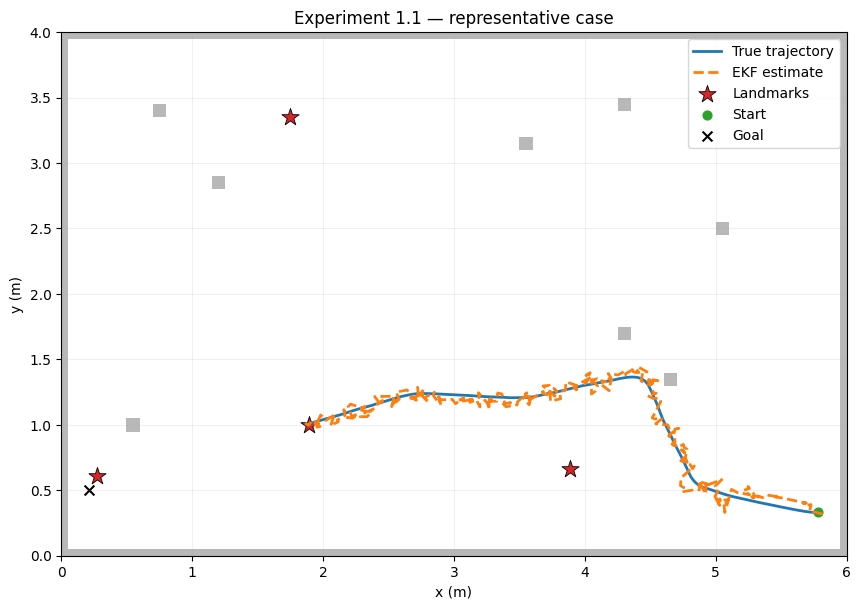

In [137]:
grid, result = known_outputs[f"known_pose_{1}"]
plot_ekf_trajectory(result, grid, title=f"Experiment 1.{1} — representative case")

As observed, the robot failed to reach its goal. This may have occurred because the simulation terminated in fewer steps than required. Nevertheless, taking into account the entire trajectory and the robot's final position, it is highly likely that the robot would reach the goal with more steps. Additionally, the EKF estimate remains highly accurate, as it closely follows the robot's ground truth.

The position and heading errors, as well as the covariance trace, are presented after executing the following cell.

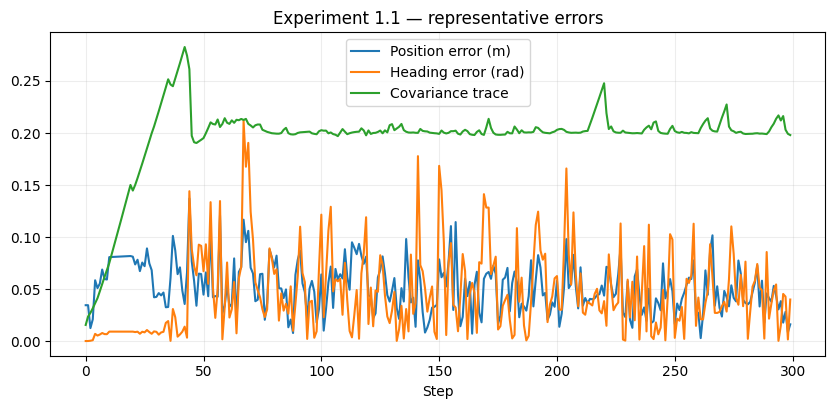

In [138]:
plot_ekf_errors(result, title=f"Experiment 1.{1} — representative errors")

The results are consistent with expectations, as they are the same as those observed in the comparison table. Several peaks are visible in the position and heading errors, which may be attributed to the robot not detecting landmarks during certain steps. However, the values throughout the simulation remain close to the previously calculated mean. A similar trend occurs in the covariance trace, which exhibits an initial peak of 0.25 before stabilising at 0.20.

The following cell presents the initial and final steps of the scene.

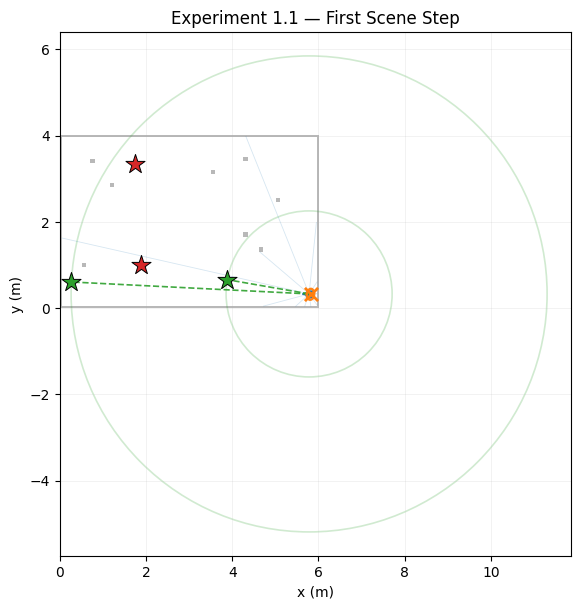

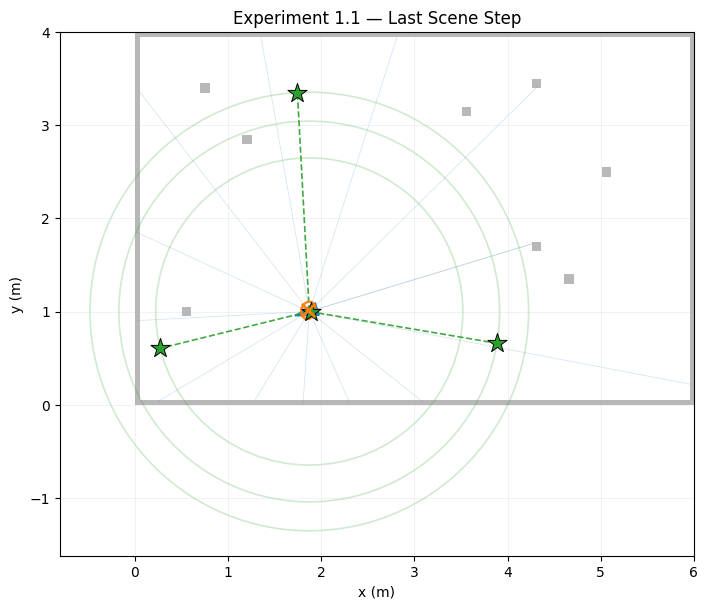

In [139]:
plot_ekf_scene(result, f"Experiment 1.{1} — First Scene Step", 0)
plot_ekf_scene(result, f"Experiment 1.{1} — Last Scene Step", -1)

As illustrated, two landmarks (green stars) are detected by the robot initially. Furthermore, its initial estimate (orange circle) matches its ground truth (blue triangle). At the end of the simulation, the estimate remains accurate. The robot observes a total of three landmarks in the final step, which likely accounts for this sustained precision.

Regarding the second case, the trajectory is plotted upon execution of the following cell.

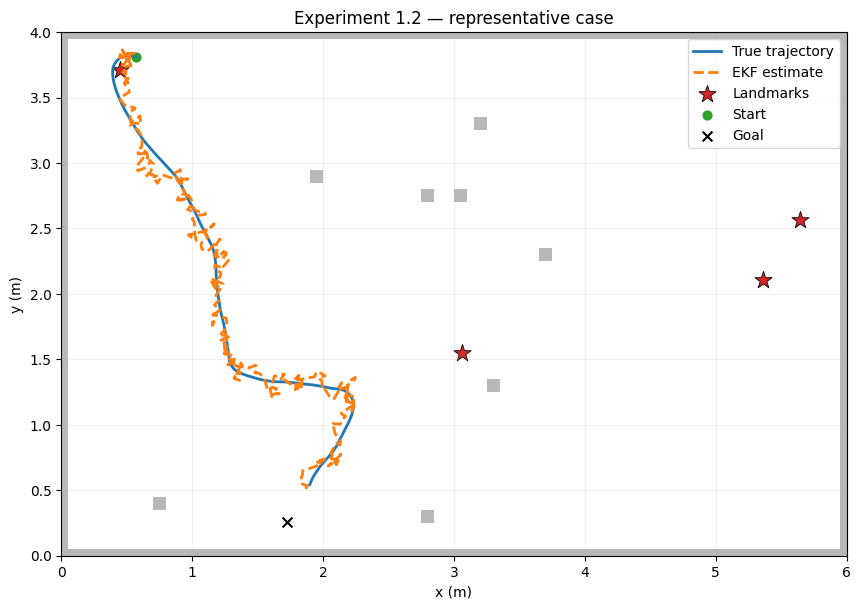

In [140]:
grid, result = known_outputs[f"known_pose_{2}"]
plot_ekf_trajectory(result, grid, title=f"Experiment 1.{2} — representative case")

Consistent with the first case, the robot fails to reach its goal. However, based on its trajectory, it is likely that the robot would achieve its objective if additional steps were provided. As previously noted, the second case exhibits a higher error than the other two. This discrepancy is evident when compared to the first trajectory. Overall, the EKF estimate remains accurate, although it is less precise than in the previous scenario.

The error metrics and covariance trace are visualised after executing the following cell.

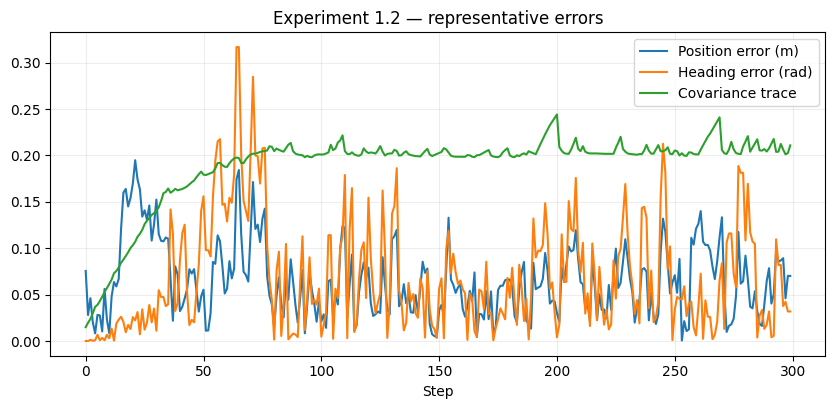

In [141]:
plot_ekf_errors(result, title=f"Experiment 1.{2} — representative errors")

Throughout the first 100 steps, there is a peak in both position and heading errors. Furthermore, this case exhibits a greater error magnitude than the previous one, as previously noted. Regarding the covariance trace, it converges after 50 steps to similar value to that of the first case.

The following cell visualises both the initial and final states of the scene.

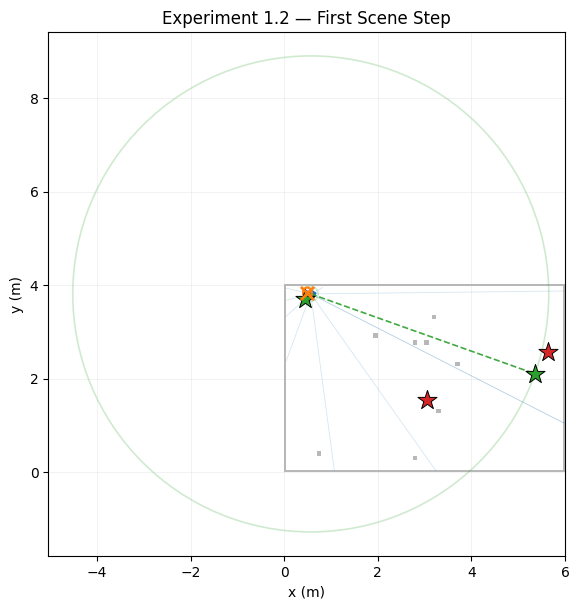

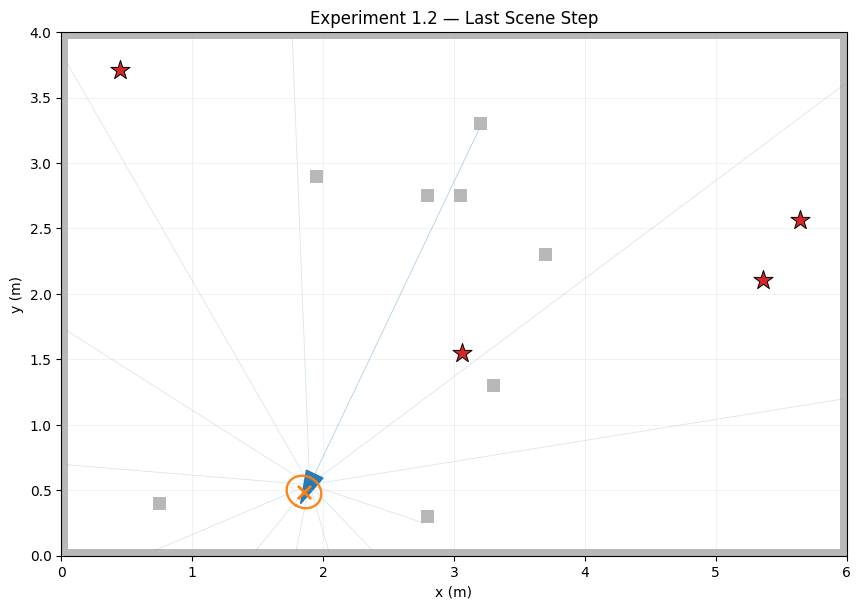

In [142]:
plot_ekf_scene(result, f"Experiment 1.{2} — First Scene Step", 0)
plot_ekf_scene(result, f"Experiment 1.{2} — Last Scene Step", -1)

Once again, the robot initially knows its position and, in this scenario, detects two landmarks. In the final step, the estimate remains accurate and close to the ground truth. However, it is less precise than in the previous case, potentially due to a lack of landmark detections.

Finally, the trajectory for the third case is visualised upon execution of the following cell.

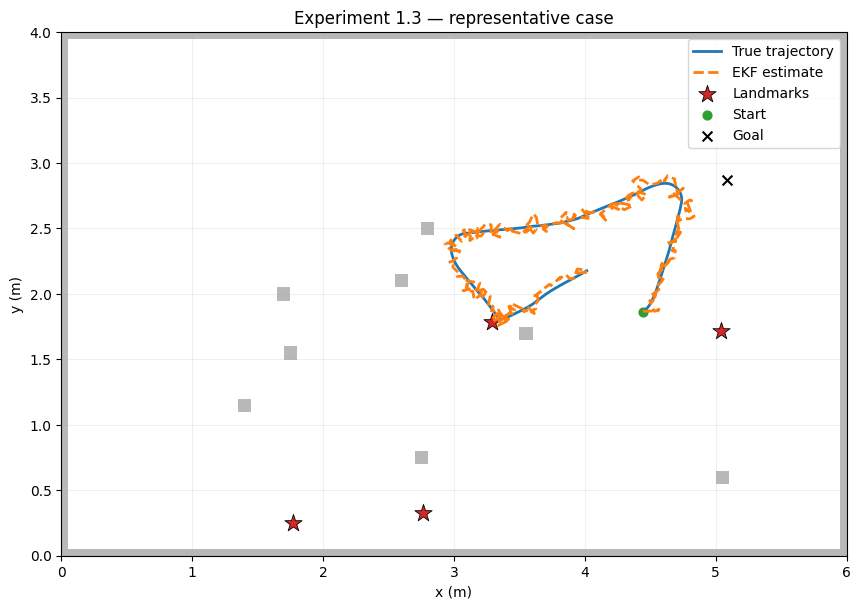

In [143]:
grid, result = known_outputs[f"known_pose_{3}"]
plot_ekf_trajectory(result, grid, title=f"Experiment 1.{3} — representative case")

In this scenario, the robot follows an erratic trajectory. This may happen because the simulation introduces five different random goals. The robot initially heads towards the first goal; however, when the target changes, likely on the left side of the map, the robot adjusts its heading accordingly. Regarding the final goal displayed, the robot reorients itself and moves directly towards the new position.

The position and heading errors, as well as the covariance trace, are displayed upon execution of the following cell.

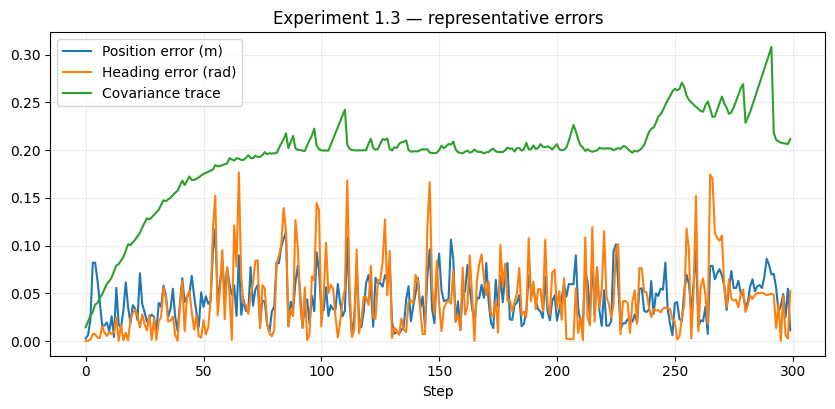

In [144]:
plot_ekf_errors(result, title=f"Experiment 1.{3} — representative errors")

Both errors are lower than in the previous scenario, with similar values to those in the first case. However, a peak in the covariance trace is observed during the final 70 steps. Considering the small peak in the heading error between steps 250 and 265, this may be attributed to a change in the goal. This event increases the robot's uncertainty regarding its position while it navigates towards the new target.

Finally, the initial and final simulation steps are visualised upon execution of the following cell.

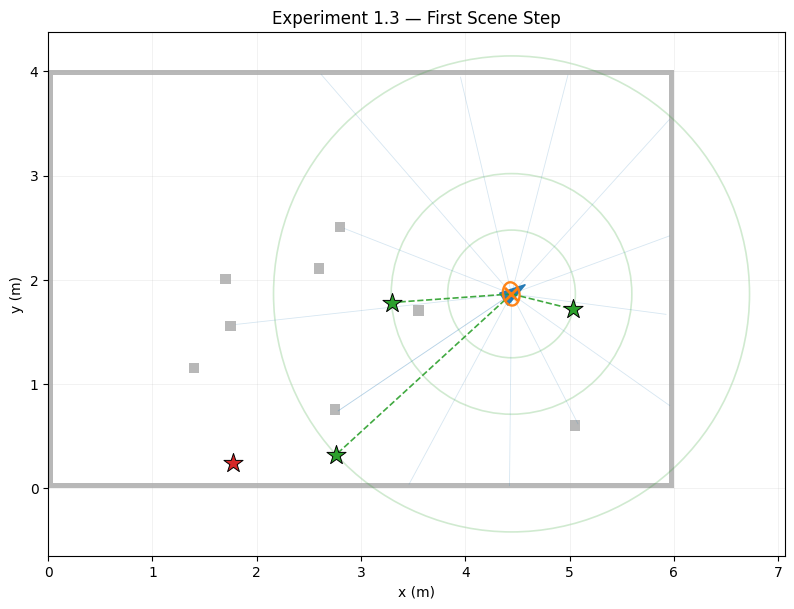

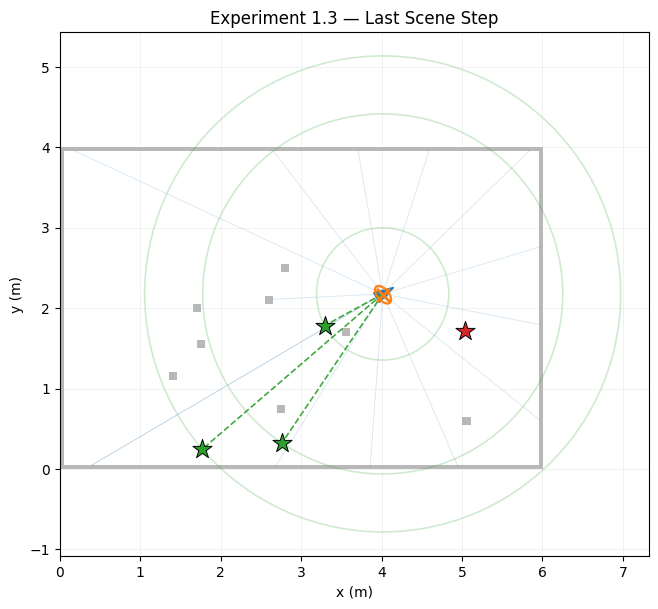

In [145]:
plot_ekf_scene(result, f"Experiment 1.{3} — First Scene Step", 0)
plot_ekf_scene(result, f"Experiment 1.{3} — Last Scene Step", -1)

As illustrated, the robot detects three landmarks in both scenes, which makes the estimate highly precise.

In general, the results attained when the initial position is known appear to be accurate. In the second case, an initial error occurred, which might have been caused by a lack of landmark detections. A similar trend is observed in the covariance trace at the end of the third case, triggered by a goal change and a corresponding adjustment in pose. However, the overall results are quite positive, validating the robustness of the EKF implementation.


## Experiment 2 — Localisation with unknown initial pose

Run the 3 cases with unknown initial pose and and report:

- A comparison of all cases
- A trajectory plot for each case
- An open discussion of the results, the changes that have been introduced (if done), and comparison with experiment 1 (using your own words)

In [146]:
unknown_cases = [
    EKFCase("unknown_pose_1", known_start=False, seed_offset=0),
    EKFCase("unknown_pose_2", known_start=False, seed_offset=1),
    EKFCase("unknown_pose_3", known_start=False, seed_offset=2),
]

unknown_df, unknown_outputs = run_ekf_cases(unknown_cases)
display(unknown_df)


,mean_pos_err,final_pos_err,mean_heading_err,final_heading_err,mean_visible_landmarks,final_cov_trace,case
0,0.065090,0.059516,0.227984,0.284264,2.32,0.211306,unknown_pose_1
1,0.066783,0.015736,2.810199,2.810199,2.36,1.961582,unknown_pose_2
2,0.051826,0.057402,0.164244,0.211385,2.23,0.225251,unknown_pose_3


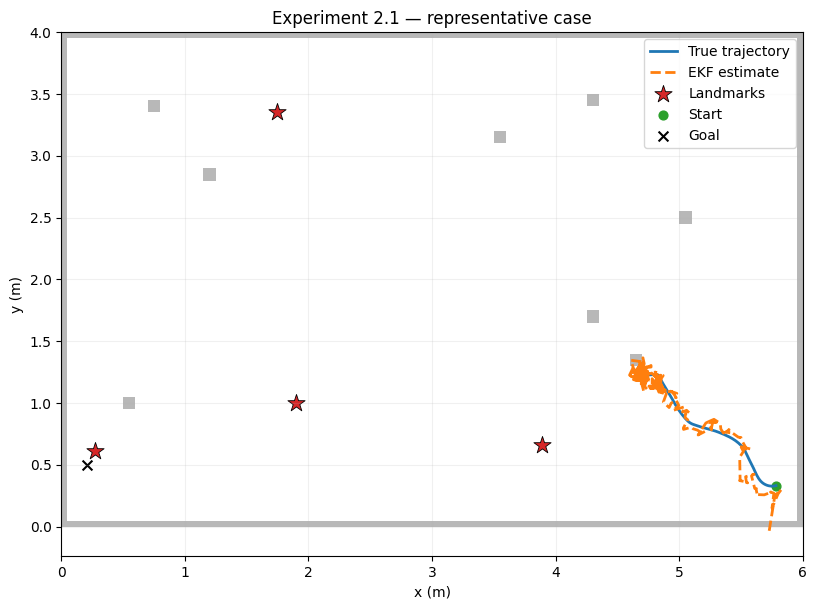

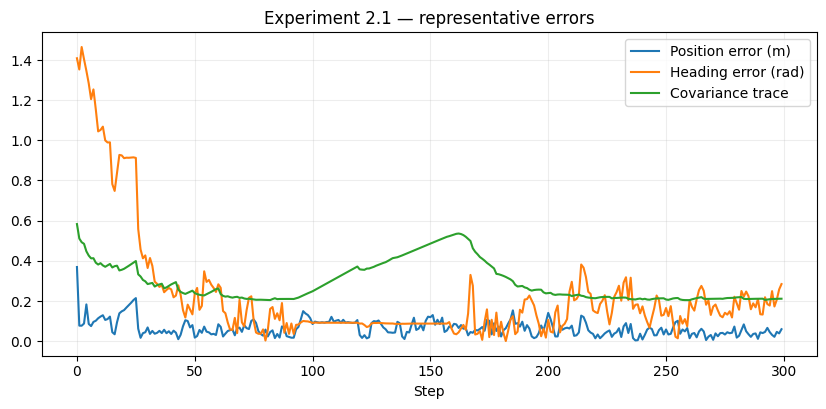

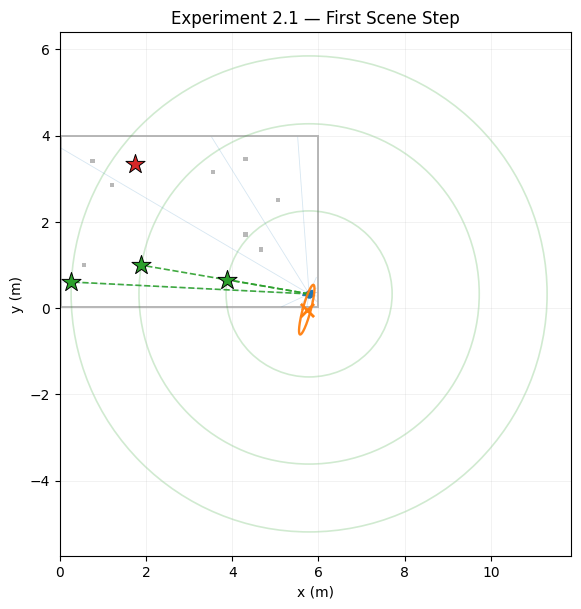

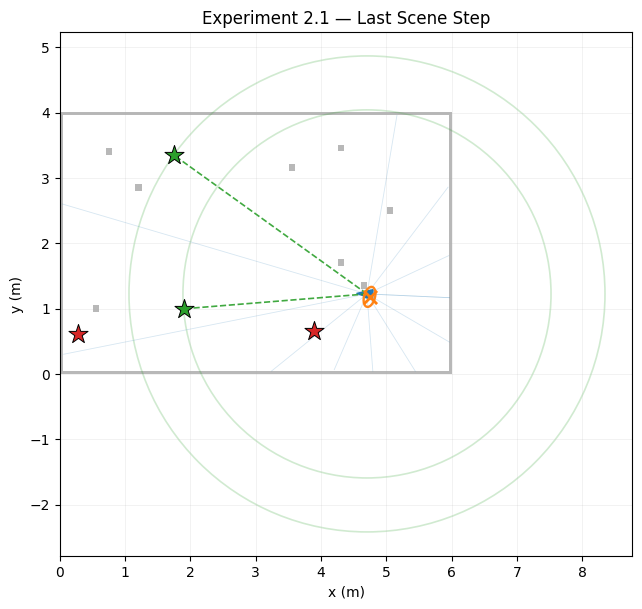

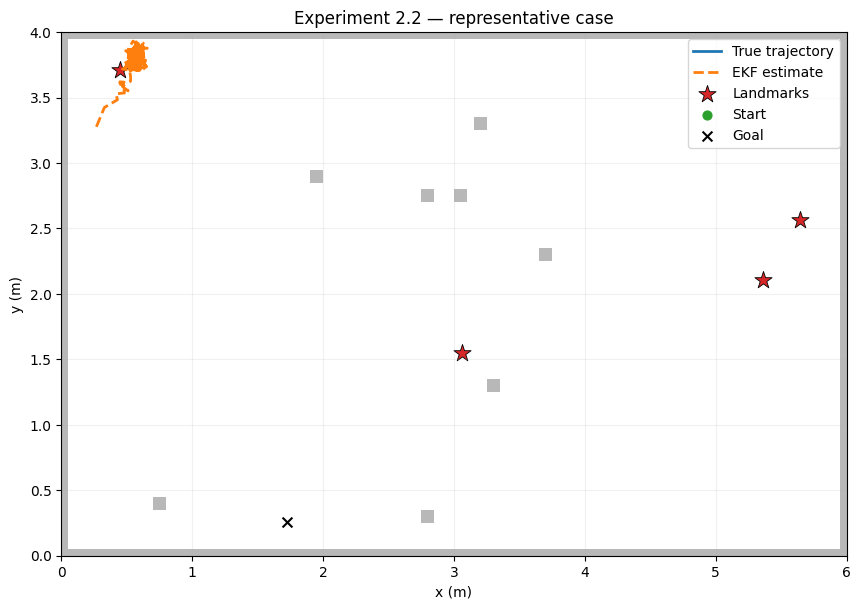

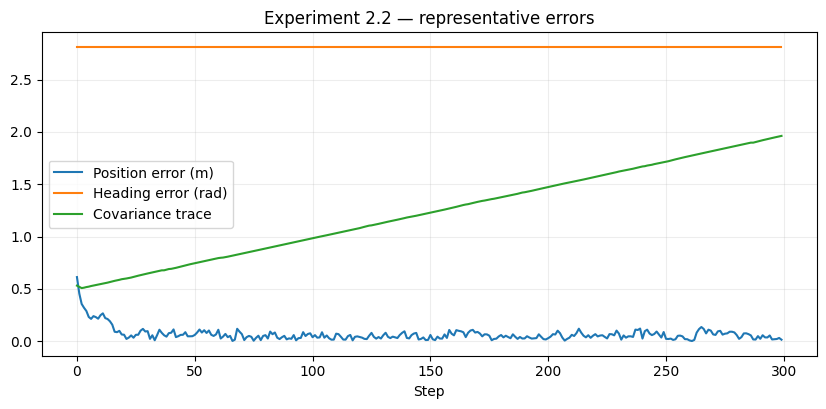

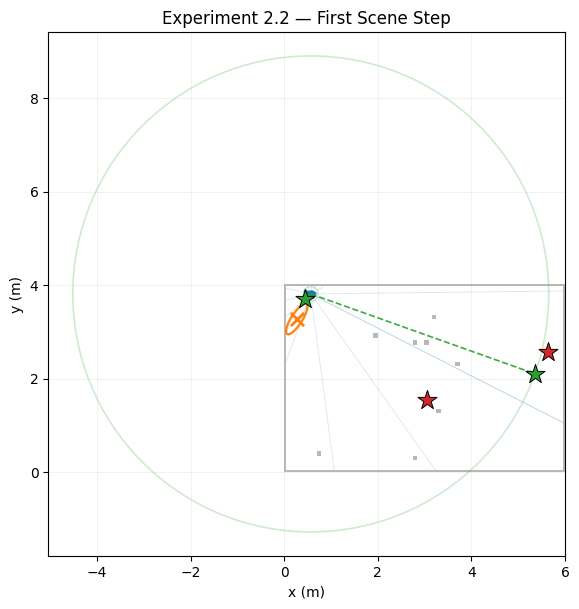

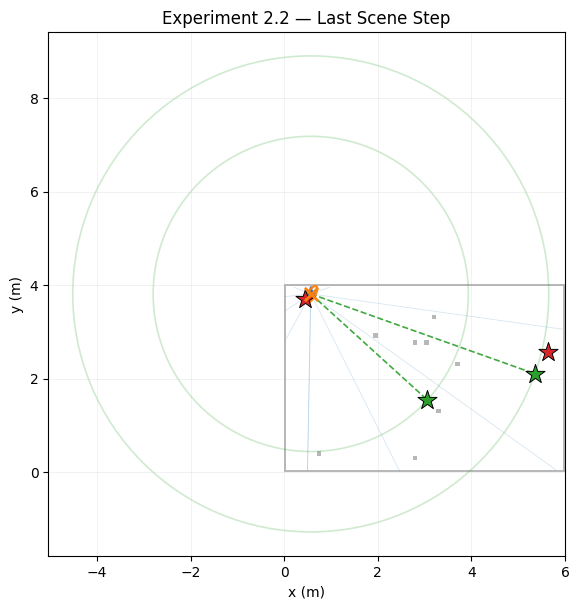

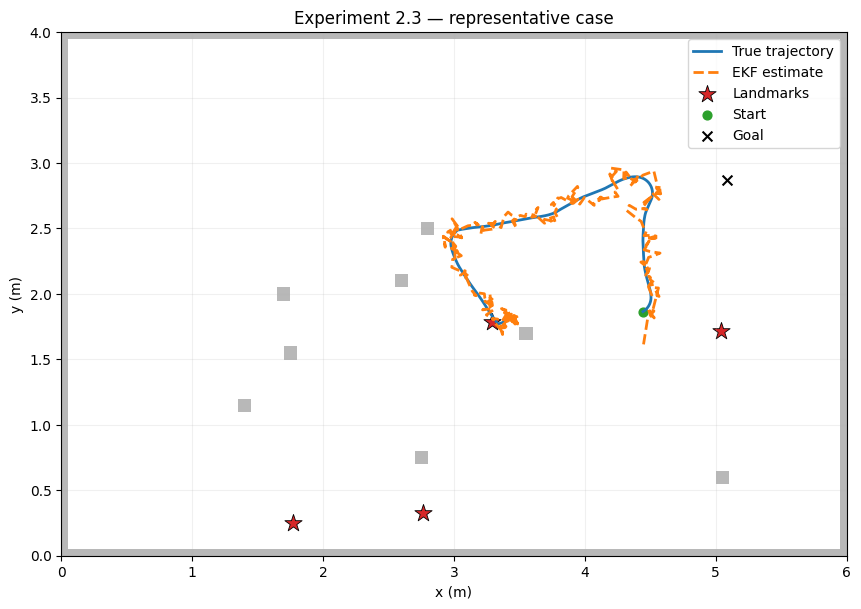

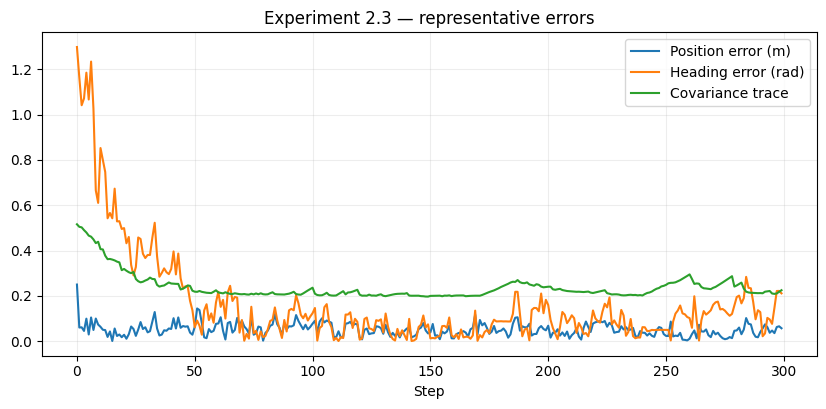

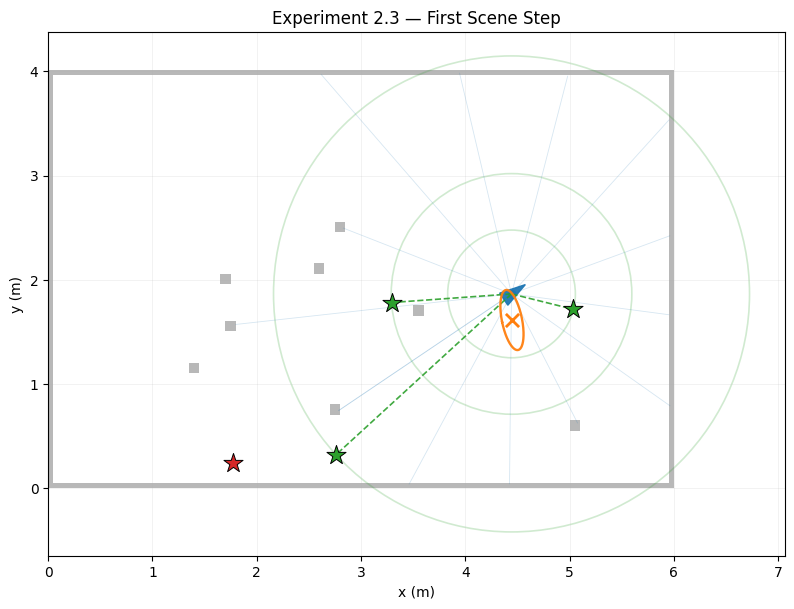

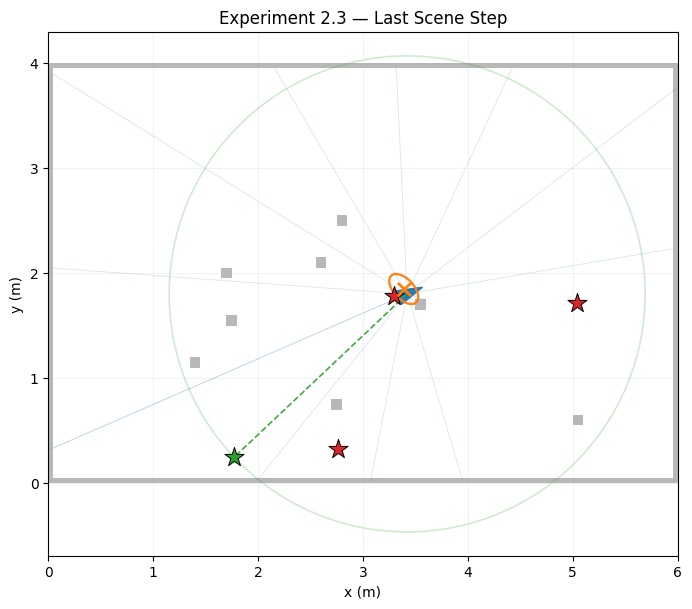

In [147]:
for index in [1,2,3]:
  grid, result = unknown_outputs[f"unknown_pose_{index}"]
  plot_ekf_trajectory(result, grid, title=f"Experiment 2.{index} — representative case")
  plot_ekf_errors(result, title=f"Experiment 2.{index} — representative errors")
  plot_ekf_scene(result, f"Experiment 2.{index} — First Scene Step", 0)
  plot_ekf_scene(result, f"Experiment 2.{index} — Last Scene Step", -1)

## Experiment 3 — Influence of noise

Run 3 cases with different values for sensor and odometry noise and report:

- A comparison of all cases
- A trajectory plot for each case
- An open discussion of the results and the influence of noise in the error and the stability (using your own words)

In [148]:
noise_settings = [
    ("low_noise", LANDMARK_SENSOR_STD*0.5, EKF_ODOM_V_STD*0.5, EKF_ODOM_W_STD*0.5),
    ("medium_noise", LANDMARK_SENSOR_STD, EKF_ODOM_V_STD, EKF_ODOM_W_STD),
    ("high_noise", LANDMARK_SENSOR_STD*4, EKF_ODOM_V_STD*4, EKF_ODOM_W_STD*4),
]

rows = []
noise_outputs = {}

for name, sensor_std, odom_v_std, odom_w_std in noise_settings:
    case = EKFCase(name=name, known_start=True, seed_offset=0)
    grid, result, summary = run_ekf_case(
        case,
        sensor_std=sensor_std,
        odom_v_std=odom_v_std,
        odom_w_std=odom_w_std,
    )
    summary["sensor_std"] = sensor_std
    summary["odom_v_std"] = odom_v_std
    summary["odom_w_std_deg"] = math.degrees(odom_w_std)
    rows.append(summary)
    noise_outputs[name] = (grid, result)

noise_df = pd.DataFrame(rows)
display(noise_df)


,mean_pos_err,final_pos_err,mean_heading_err,final_heading_err,mean_visible_landmarks,final_cov_trace,case,sensor_std,odom_v_std,odom_w_std_deg
0,0.037805,0.029416,0.038459,0.008936,2.380000,0.193750,low_noise,0.04,0.02,2.0
1,0.051963,0.016235,0.045857,0.040054,2.616667,0.198033,medium_noise,0.08,0.04,4.0
2,0.110915,0.121853,0.099559,0.141055,2.563333,0.233610,high_noise,0.32,0.16,16.0


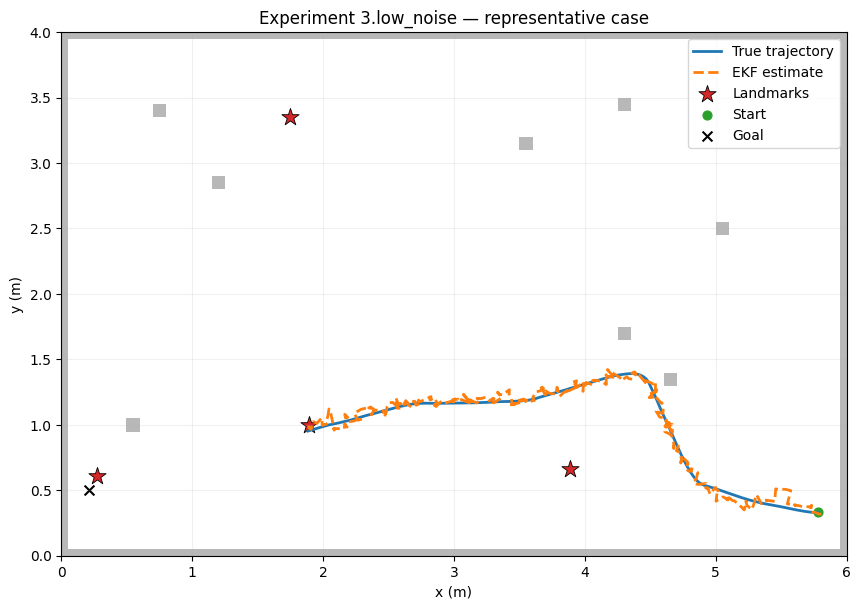

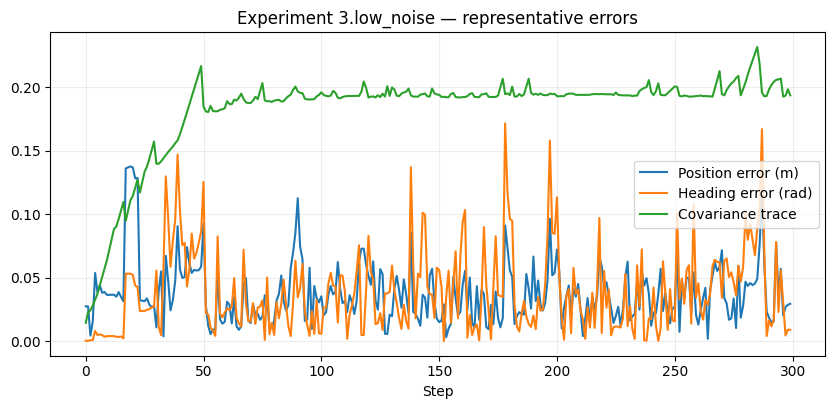

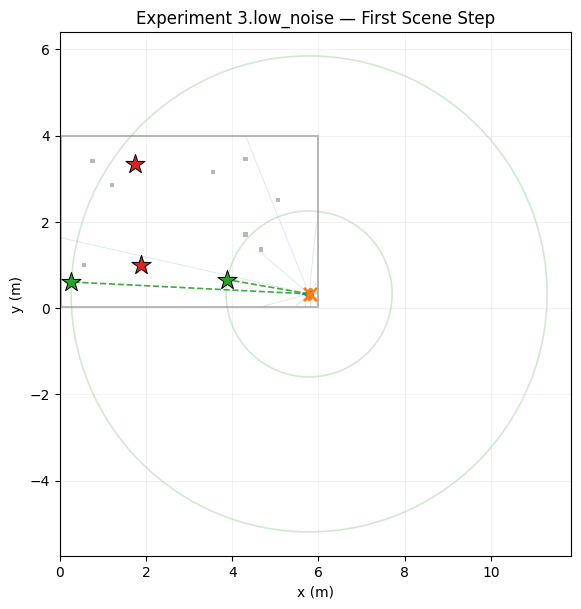

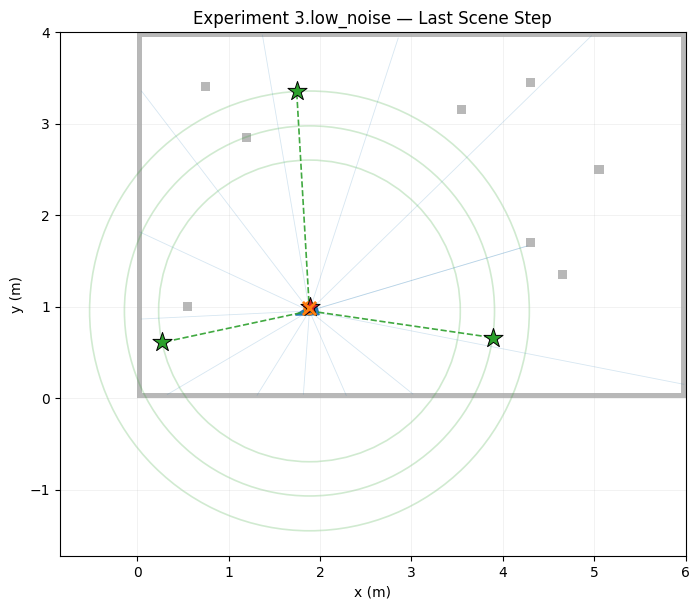

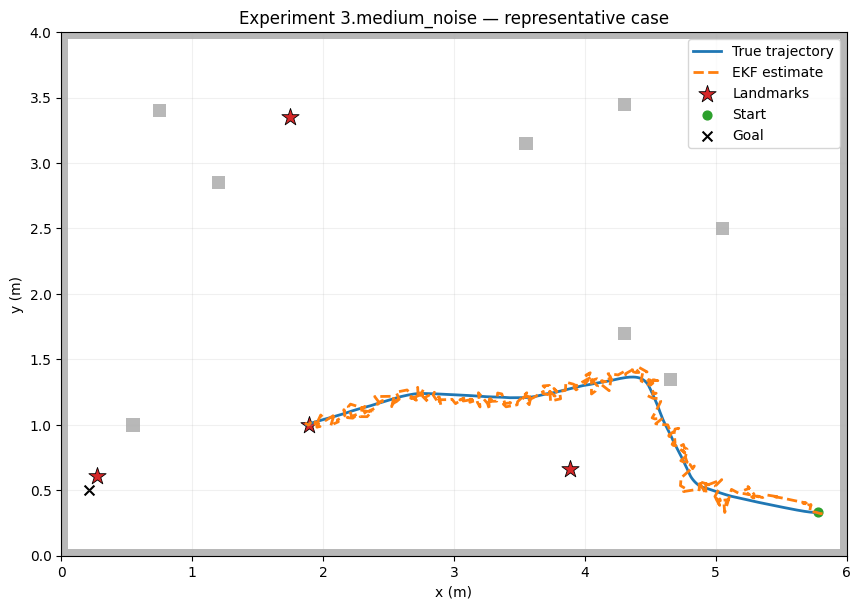

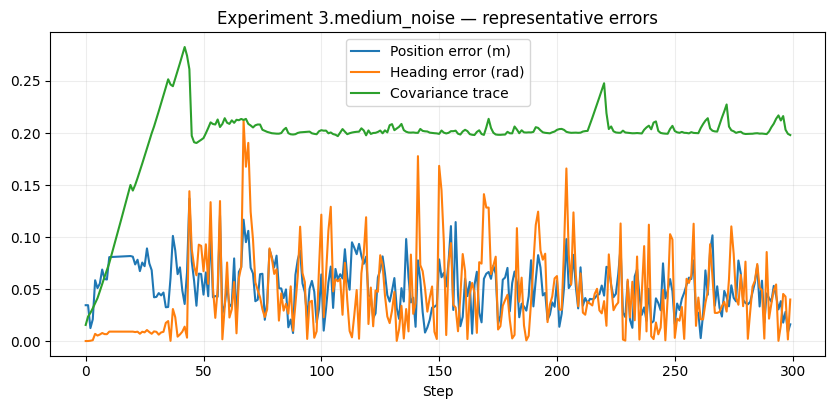

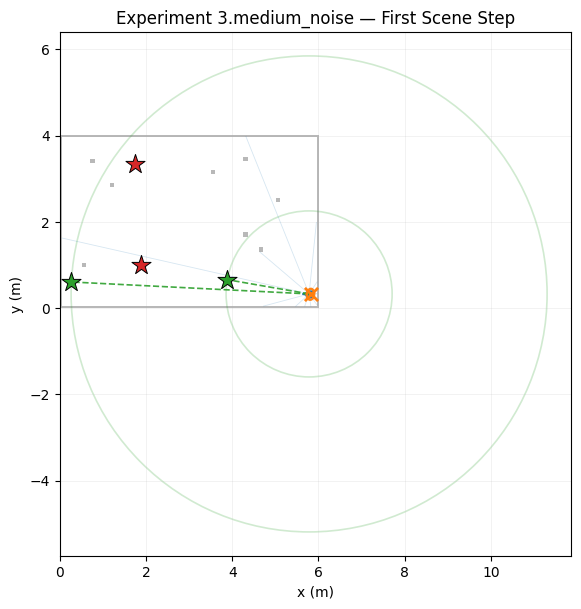

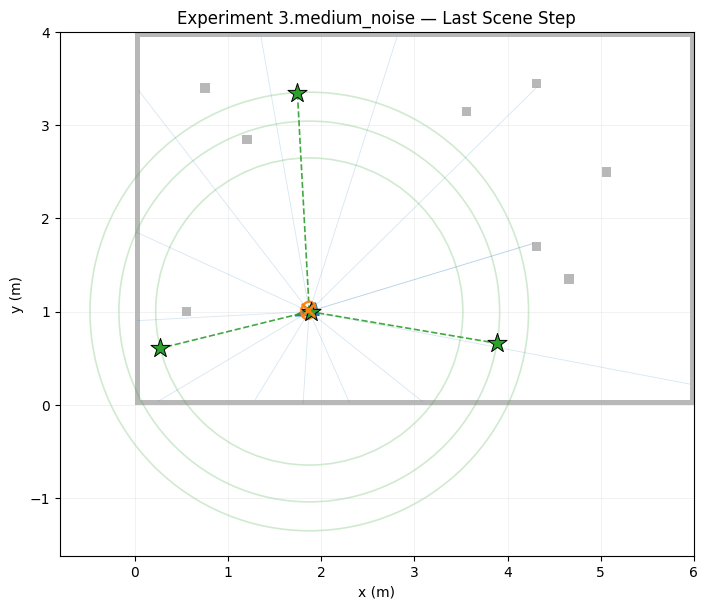

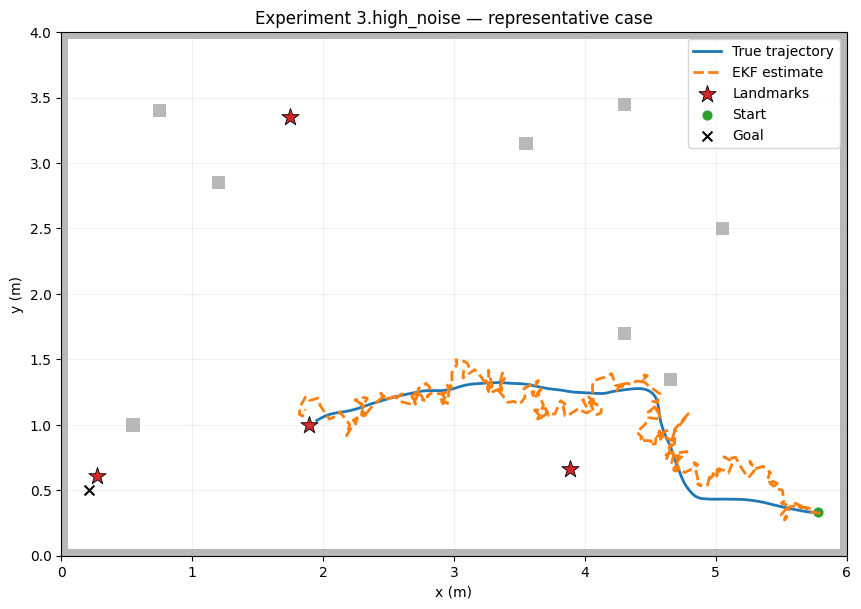

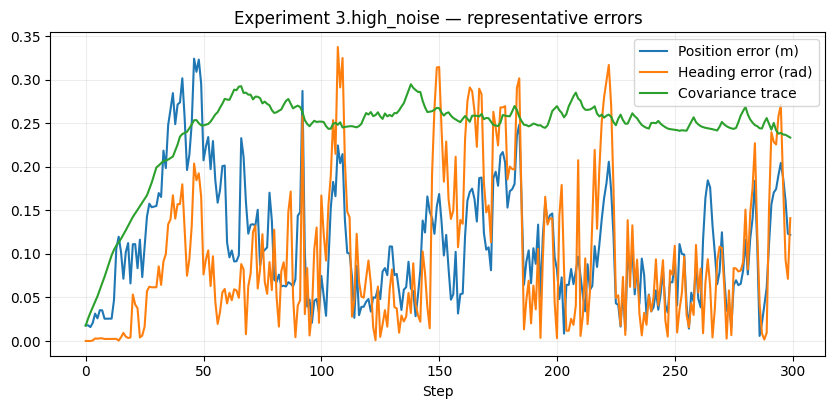

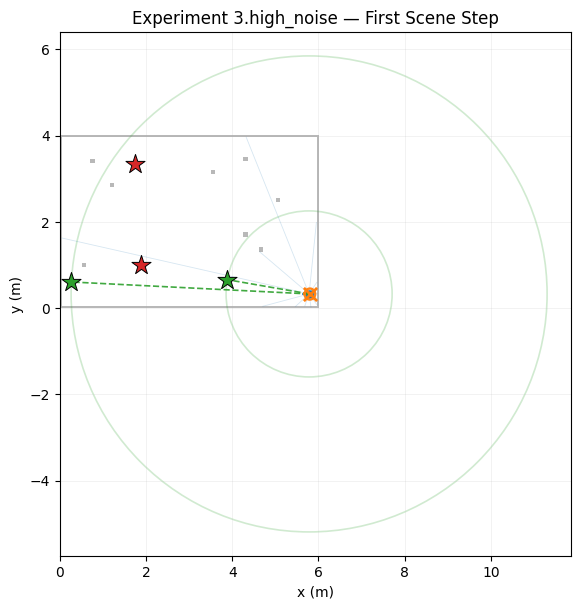

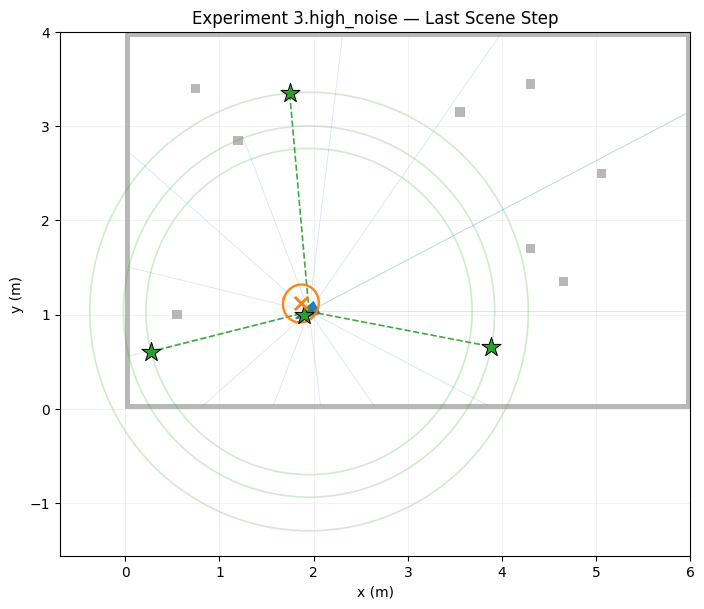

In [149]:

for noise_level in ["low","medium","high"]:
  grid, result = noise_outputs[f"{noise_level}_noise"]
  plot_ekf_trajectory(result, grid, title=f"Experiment 3.{noise_level}_noise — representative case")
  plot_ekf_errors(result, title=f"Experiment 3.{noise_level}_noise — representative errors")
  plot_ekf_scene(result, f"Experiment 3.{noise_level}_noise — First Scene Step", 0)
  plot_ekf_scene(result, f"Experiment 3.{noise_level}_noise — Last Scene Step", -1)


## Submission checklist

Before submitting, make sure that:

- All opened functions are completed
- The notebook runs from top to bottom without execution errors
- The three experiments are included

In [150]:
# Add as many cells as needed.